## Settings & imports

In [1]:
import numpy as np
import pandas as pd
import os
import torch
import matplotlib.pyplot as plt
import string
from torch import nn
from torch.utils.data import Dataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
import csv

In [2]:
import json

with open('../config.json', 'r') as f:
    config = json.load(f)

which_dataset = config["which_dataset"]
    
preprocessing_method = config["preprocessing_method"] # normalization / logarithm
remove_outer_bool = config["remove_outer"]
how_many_outer_to_remove = config["how_many_outer_to_remove"]
elements_to_keep = config["elements_to_keep"][which_dataset]

target_path = config["target_path"][which_dataset]
results_path = config["results_path"]
figures_path = config["figures_path"]
models_path = config["models_path"][which_dataset]

In [3]:
columns_to_keep_inds = [el + '_i' for el in elements_to_keep]

## Loading the data

In [4]:
if which_dataset == 'old':
    inds_df = pd.read_csv(target_path, usecols = elements_to_keep + ['probka'])
    inds_df.rename(columns={"probka": "Sample_id"}, inplace=True)
elif which_dataset == 'new':
    inds_df = pd.read_csv(target_path, usecols = elements_to_keep + ['name'])
    inds_df['Sample_id'] = inds_df['name'].apply(lambda x: x.split('_')[0] if len(x.split('_'))==2 else x.split('_')[0] + x.split('_')[1])
    inds_df.drop(columns=['name'], inplace=True)

In [5]:
inds_df

,Mg,Al,S,Cr,Mn,Fe,Co,Cu,Zn,Pb,Sample_id
0,1392.95556,135.27778,1038.34444,3.14074,1822.41111,10775.97778,61.28889,527.55556,2923.55556,25.11111,APP.0
1,1378.73333,142.27778,1138.67778,4.17037,1950.63333,10103.97778,69.84444,536.55556,2974.33333,27.00000,APP.0
2,1244.40000,126.61111,994.56667,1.00000,1701.74444,9589.86667,60.84444,545.33333,2850.55556,27.44444,APP.0
3,1301.95556,125.94444,834.45556,3.14074,1723.41111,9127.86667,56.95556,491.00000,2770.88889,30.22222,APP.0
4,1242.28889,137.61111,950.45556,4.36296,1643.07778,8833.86667,57.51111,478.00000,2620.11111,25.88889,APP.0
...,...,...,...,...,...,...,...,...,...,...,...
2095,292.03333,200.72222,181.96667,4.26667,325.47778,4830.52222,39.91111,371.87778,816.86667,106.08889,ML9C
2096,254.92222,259.94444,205.30000,5.31111,313.70000,4327.07778,40.91111,353.10000,715.75556,49.53333,ML9C
2097,245.81111,246.16667,174.30000,6.35556,258.92222,3965.07778,37.80000,340.32222,787.97778,41.97778,ML9C
2098,204.47778,172.05556,115.30000,8.86667,243.92222,3728.96667,32.80000,345.65556,677.20000,46.53333,ML9C


## Preprocessing

In [6]:
inds_df = inds_df.reset_index(drop=True)

### Removing some data

1. Let's remove 'outer' samples.

In [7]:
def remove_outer(group, n):
    return group.iloc[n:-n] if len(group) > 2*n else pd.DataFrame(columns=group.columns)

In [8]:
if remove_outer_bool:
    inDKs_df = inDKs_df.groupby('Sample_id', group_keys=False).apply(remove_outer, n=how_many_outer_to_remove)

2. Let's keep only columns that we need.

To reduce the set of used elements run cell below. Then, instead of predicting 29 numbers, we will predict only 8. We will also use only 8 numbers as input.

In [9]:
inds_df = inds_df[elements_to_keep]

In [10]:
inds_df.rename(columns=dict([(el, el+'_i') for el in elements_to_keep]), inplace=True)

3. Let's remove rows with missing values.

In [11]:
(inds_df.shape[0] - inds_df.dropna().shape[0])/inds_df.shape[0]

0.0

In [12]:
inds_df.dropna(inplace=True)

4. Let's set negative numbers to zeros. (First, check if there are any.)

In [13]:
(inds_df[columns_to_keep_inds]<0).sum().sum() == 0

np.True_

In [14]:
for col in columns_to_keep_inds:
    inds_df[col][inds_df[col] < 0] = 0

/tmp/ipykernel_11826/1332208633.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  inds_df[col][inds_df[col] < 0] = 0
/tmp/ipykernel_11826/1332208633.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are 

5. Let's multiply the values by weights.

In [15]:
if which_dataset == "new":
    
    #Al, S, Cr, Mn, Co, Cu, Zn, Pb, Fe, Mg
    custom_weights = [1, 1, 1, 10, 19, 20, 17, 9, 20, 1]
    weights = [el/sum(custom_weights) for el in custom_weights]
    
    for i, col in enumerate(columns_to_keep_inds):
        inds_df[col] = weights[i]*inds_df[col]

6. Normalize with respect to Fe and remove Fe.

In [16]:
# for i, col in enumerate(columns_to_keep_inds):
#     inds_df[col] = inds_df[col] / inds_df['Fe_i']

In [17]:
# inds_df.drop(columns=['Fe_i'], inplace=True)
# columns_to_keep_inds.remove('Fe_i')

7. Store the data as a numpy array.

In [18]:
X = np.array(inds_df.values)

### Normalizing / taking logarithm

In [19]:
def adjusted_log_transform(input_array):
    res = np.where(input_array>0, np.log(input_array), 0.)
    return res

In [20]:
if preprocessing_method == 'normalization':

    X = (X - np.min(X, axis=0))/np.std(X, axis=0)
    
elif preprocessing_method == 'logarithm':
    
    X = adjusted_log_transform(X)

elif preprocessing_method == 'logarithm_and_normalization':
    
    #logarithm
    X = adjusted_log_transform(X)
    
    #normalization
    X = (X - np.min(X, axis=0))/np.std(X, axis=0)

elif preprocessing_method == 'none':
    
    pass

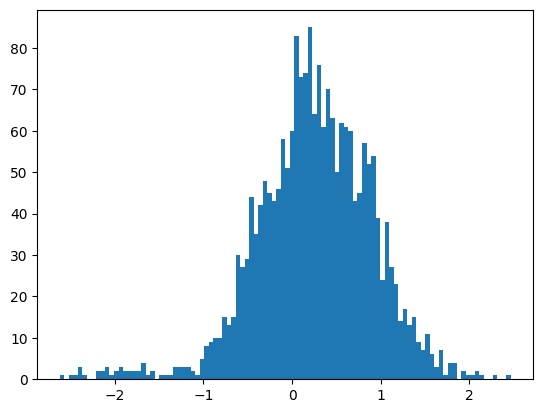

In [30]:
coor = 0
plt.hist(X[:,coor], bins=100);

### Converting to tensors

In [31]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [32]:
X = torch.Tensor(X).to(device)

## Loading the trained model

### Model class

In [33]:
input_size = X.shape[1]

In [34]:
dropout_prob = 0.02

class InksNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.seq = nn.Sequential(
        nn.Linear(input_size, 32),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(32, 64),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(64, 128),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(128, 256),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(256, 512),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(512, 1024),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(1024, 512),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(512, 256),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(256, 128),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(64, 32),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(32, input_size))
    def forward(self, x):
        return self.seq(x)

### Loading

In [35]:
models_path

'../models/Documents_XVIII_century/model_regression_logarithm_outer_removed_1_Al_S_Cr_Mn_Co_Cu_Zn_Pb_Fe_Mg_2025_08_25_13_06_06'

In [36]:
model = InksNet().to(device)
model.load_state_dict(torch.load(models_path, map_location=torch.device('cpu')))

/tmp/ipykernel_11826/3976278578.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(models_path, map_location=torch.device('cpu')))


<All keys matched successfully>

## Prediction

In [37]:
model.eval()
outputs = model(X)

## Saving result to a file

In [38]:
model_name = models_path.split('/')[-1]

In [39]:
outputs_to_save = outputs.cpu().detach().numpy()

In [40]:
np.savetxt(results_path + 'prediction_for_' + which_dataset + '_dataset_from_' + model_name, outputs_to_save, delimiter=',')